https://www.mdpi.com/1424-8220/25/18/5877

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Objective function ----------

def sphere(x):
    return np.sum(x**2)

bounds = (-5, 5)
low, high = bounds

# ---------- Instrumented algorithms: return trajectory of best-so-far ----------

def pio_traj(f, dim=2, n_pigeons=30, iters=50, bounds=(-5, 5)):
    low, high = bounds
    switch_iter = iters // 2

    X = np.random.uniform(low, high, size=(n_pigeons, dim))
    V = np.zeros_like(X)

    best_pos = X[0].copy()
    best_fit = f(best_pos)
    traj = []

    for t in range(iters):
        fitness = np.array([f(x) for x in X])
        idx_best = np.argmin(fitness)
        if fitness[idx_best] < best_fit:
            best_fit = fitness[idx_best]
            best_pos = X[idx_best].copy()

        traj.append(best_pos.copy())

        if t < switch_iter:
            # Map & compass stage
            R = np.random.rand(*X.shape)
            V = V + R * (best_pos - X)
            X = X + V
        else:
            # Landmark stage
            order = np.argsort(fitness)
            survivors = order[: len(order) // 2]
            X = X[survivors]
            center = np.mean(X, axis=0)
            R = np.random.rand(*X.shape)
            X = X + R * (center - X)

        X = np.clip(X, low, high)

    return np.array(traj)


def ssa_traj(f, dim=2, n_salp=30, iters=50, bounds=(-5, 5)):
    import math
    low, high = bounds

    X = np.random.uniform(low, high, size=(n_salp, dim))
    fitness = np.array([f(x) for x in X])
    best_idx = np.argmin(fitness)
    food = X[best_idx].copy()
    food_fit = fitness[best_idx]

    traj = []

    for t in range(1, iters + 1):
        c1 = 2 * math.exp(-((4 * t / iters) ** 2))

        for i in range(n_salp):
            if i == 0:
                # Leader
                c2 = np.random.rand(dim)
                c3 = np.random.rand(dim)
                direction = np.where(c3 >= 0.5, 1, -1)
                X[i] = food + direction * c1 * ((high - low) * c2 + low)
            else:
                # Followers
                X[i] = (X[i] + X[i - 1]) / 2.0

        X = np.clip(X, low, high)

        fitness = np.array([f(x) for x in X])
        idx = np.argmin(fitness)
        if fitness[idx] < food_fit:
            food_fit = fitness[idx]
            food = X[idx].copy()

        traj.append(food.copy())

    return np.array(traj)


def abc_traj(f, dim=2, n_food=20, iters=50, bounds=(-5, 5), limit=10):
    import random
    low, high = bounds

    foods = np.random.uniform(low, high, size=(n_food, dim))
    fitness = np.array([f(x) for x in foods])
    trials = np.zeros(n_food)
    traj = []

    def random_neighbor(x):
        k = random.randint(0, dim - 1)
        v = x.copy()
        phi = random.uniform(-1, 1)
        v[k] += phi * (high - low)
        return np.clip(v, low, high)

    for _ in range(iters):
        # Employed phase
        for i in range(n_food):
            v = random_neighbor(foods[i])
            fv = f(v)
            if fv < fitness[i]:
                foods[i], fitness[i] = v, fv
                trials[i] = 0
            else:
                trials[i] += 1

        # Onlooker phase
        inv_fit = 1.0 / (1.0 + fitness)
        probs = inv_fit / np.sum(inv_fit)
        for _ in range(n_food):
            i = np.random.choice(np.arange(n_food), p=probs)
            v = random_neighbor(foods[i])
            fv = f(v)
            if fv < fitness[i]:
                foods[i], fitness[i] = v, fv
                trials[i] = 0
            else:
                trials[i] += 1

        # Scout phase
        for i in range(n_food):
            if trials[i] > limit:
                foods[i] = np.random.uniform(low, high, size=dim)
                fitness[i] = f(foods[i])
                trials[i] = 0

        best_idx = np.argmin(fitness)
        traj.append(foods[best_idx].copy())

    return np.array(traj)


def aco_traj(f, dim=2, n_ants=20, iters=50, bounds=(-5, 5), evaporation=0.5):
    low, high = bounds
    pheromone = np.ones(dim)
    best_pos = np.random.uniform(low, high, size=dim)
    best_val = f(best_pos)

    traj = []

    for _ in range(iters):
        for _ in range(n_ants):
            sigma = (high - low) / (1 + pheromone)
            pos = np.random.normal(0, sigma, size=dim)
            pos = np.clip(pos, low, high)
            v = f(pos)
            if v < best_val:
                best_val = v
                best_pos = pos.copy()

        pheromone *= (1 - evaporation)
        pheromone += 1.0 / (1.0 + best_val)

        traj.append(best_pos.copy())

    return np.array(traj)


def pso_traj(f, dim=2, n_particles=30, iters=50, bounds=(-5, 5),
             w=0.7, c1=1.5, c2=1.5):
    low, high = bounds

    X = np.random.uniform(low, high, size=(n_particles, dim))
    V = np.random.uniform(-abs(high - low), abs(high - low),
                          size=(n_particles, dim))

    pbest = X.copy()
    pbest_val = np.array([f(x) for x in X])

    gbest_idx = np.argmin(pbest_val)
    gbest = pbest[gbest_idx].copy()
    gbest_val = pbest_val[gbest_idx]

    traj = []

    for _ in range(iters):
        r1 = np.random.rand(n_particles, dim)
        r2 = np.random.rand(n_particles, dim)

        V = w * V + c1 * r1 * (pbest - X) + c2 * r2 * (gbest - X)
        X = X + V
        X = np.clip(X, low, high)

        vals = np.array([f(x) for x in X])
        improved = vals < pbest_val
        pbest[improved] = X[improved]
        pbest_val[improved] = vals[improved]

        gbest_idx = np.argmin(pbest_val)
        if pbest_val[gbest_idx] < gbest_val:
            gbest_val = pbest_val[gbest_idx]
            gbest = pbest[gbest_idx].copy()

        traj.append(gbest.copy())

    return np.array(traj)


def ga_traj(f, dim=2, pop_size=30, iters=50, bounds=(-5, 5),
            crossover_rate=0.8, mutation_rate=0.1):
    low, high = bounds
    pop = np.random.uniform(low, high, size=(pop_size, dim))

    def fitness(x):
        return -f(x)

    traj = []

    for _ in range(iters):
        fit_vals = np.array([fitness(ind) for ind in pop])
        best_idx = np.argmax(fit_vals)
        traj.append(pop[best_idx].copy())

        def select():
            a, b = np.random.randint(0, pop_size, size=2)
            return pop[a] if fit_vals[a] > fit_vals[b] else pop[b]

        new_pop = []
        while len(new_pop) < pop_size:
            parent1 = select()
            parent2 = select()

            # Crossover
            if np.random.rand() < crossover_rate:
                alpha = np.random.rand(dim)
                child1 = alpha * parent1 + (1 - alpha) * parent2
                child2 = alpha * parent2 + (1 - alpha) * parent1
            else:
                child1, child2 = parent1.copy(), parent2.copy()

            # Mutation
            for child in (child1, child2):
                for d in range(dim):
                    if np.random.rand() < mutation_rate:
                        child[d] += np.random.normal(0, 0.1 * (high - low))
                child[:] = np.clip(child, low, high)
                new_pop.append(child)
                if len(new_pop) == pop_size:
                    break

        pop = np.array(new_pop)

    return np.array(traj)

# ---------- Generate trajectories ----------

traj_pio = pio_traj(sphere)
traj_ssa = ssa_traj(sphere)
traj_abc = abc_traj(sphere)
traj_aco = aco_traj(sphere)
traj_pso = pso_traj(sphere)
traj_ga  = ga_traj(sphere)

# ---------- Plot on contour of the sphere function ----------

x = np.linspace(low, high, 200)
y = np.linspace(low, high, 200)
Xg, Yg = np.meshgrid(x, y)
Z = Xg**2 + Yg**2

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
algos = [("PIO", traj_pio), ("SSA", traj_ssa), ("ABC", traj_abc),
         ("ACO", traj_aco), ("PSO", traj_pso), ("GA", traj_ga)]

for ax, (name, traj) in zip(axes.ravel(), algos):
    cs = ax.contour(Xg, Yg, Z, levels=20, cmap='viridis')
    ax.plot(traj[:, 0], traj[:, 1],
            marker='o', markersize=2, linewidth=1, color='red')
    ax.set_title(name)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)

plt.tight_layout()
plt.show()

/home/roel/CTAI/Industry_Project/vslam/research/swarm_navigation/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/roel/CTAI/Industry_Project/vslam/research/swarm_navigation/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


ValueError: attempt to get argmin of an empty sequence

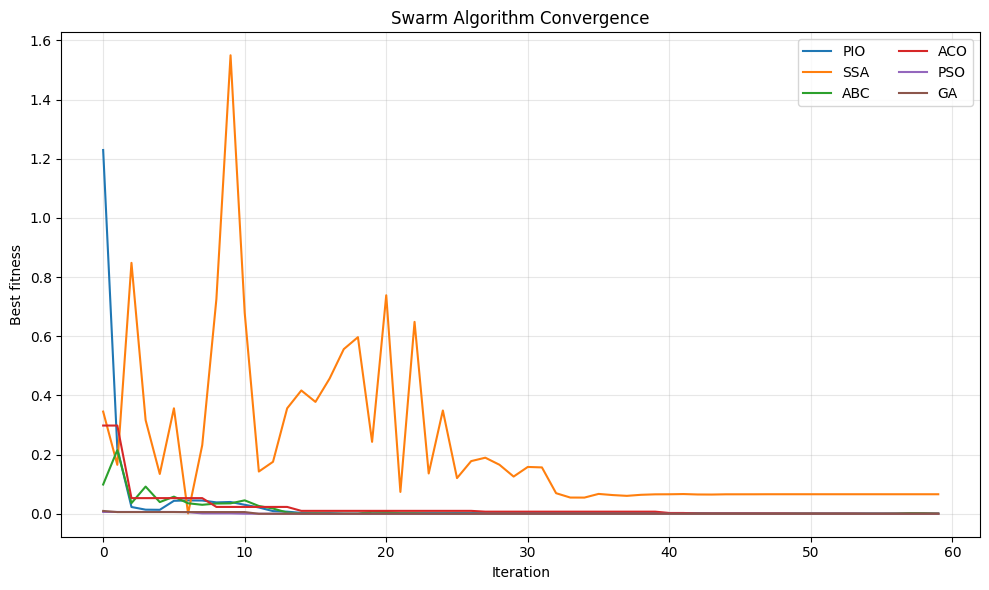

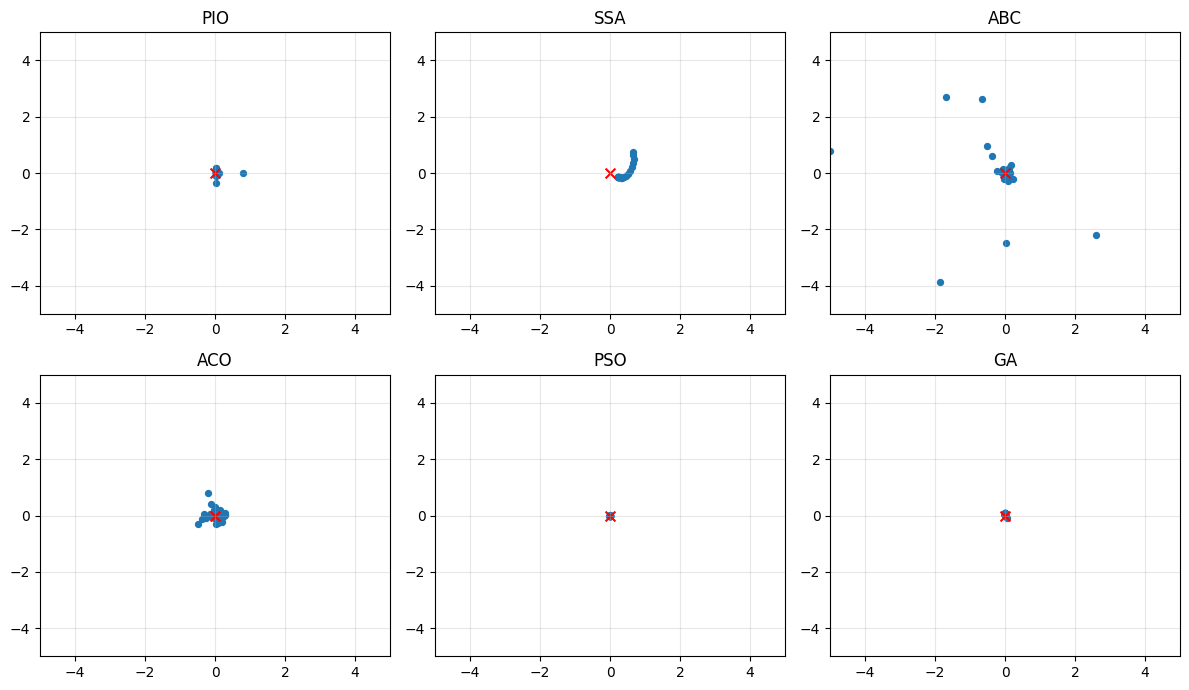

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

np.random.seed(7)
random.seed(7)

# Objective function: minimize the Sphere function
def f(X):
    X = np.asarray(X)
    return np.sum(X**2, axis=-1)

bounds = (-5, 5)
dim = 2
n = 25
iters = 60

# ---------- PSO ----------
pos = np.random.uniform(*bounds, size=(n, dim))
vel = np.random.uniform(-1, 1, size=(n, dim))
pbest = pos.copy()
pbest_val = f(pos)
gbest = pbest[np.argmin(pbest_val)].copy()
gbest_val = pbest_val.min()
pso_hist = []
pso_pos_hist = []

for t in range(iters):
    r1, r2 = np.random.rand(n, dim), np.random.rand(n, dim)
    vel = 0.7 * vel + 1.5 * r1 * (pbest - pos) + 1.5 * r2 * (gbest - pos)
    pos = np.clip(pos + vel, *bounds)

    vals = f(pos)
    improved = vals < pbest_val
    pbest[improved] = pos[improved]
    pbest_val[improved] = vals[improved]

    idx = np.argmin(pbest_val)
    if pbest_val[idx] < gbest_val:
        gbest_val = pbest_val[idx]
        gbest = pbest[idx].copy()

    pso_hist.append(gbest_val)
    pso_pos_hist.append(pos.copy())

# ---------- GA ----------
pop = np.random.uniform(*bounds, size=(n, dim))
ga_hist = []
ga_best = []

for t in range(iters):
    vals = f(pop)
    elite = pop[np.argsort(vals)[:4]]

    probs = 1 / (vals + 1e-9)
    probs = probs / probs.sum()

    new_pop = [e.copy() for e in elite]
    while len(new_pop) < n:
        p1, p2 = pop[np.random.choice(n, 2, p=probs, replace=False)]
        cp = np.random.randint(1, dim)
        child = np.r_[p1[:cp], p2[cp:]]
        if np.random.rand() < 0.3:
            child += np.random.normal(0, 0.3, size=dim)
        new_pop.append(np.clip(child, *bounds))

    pop = np.array(new_pop)
    best = pop[np.argmin(f(pop))]
    ga_best.append(best.copy())
    ga_hist.append(f(best))

# ---------- SSA ----------
salp = np.random.uniform(*bounds, size=(n, dim))
ssa_hist = []
ssa_pos_hist = []

for t in range(iters):
    vals = f(salp)
    food = salp[np.argmin(vals)].copy()
    c1 = 2 * math.exp(-(4 * (t / iters)) ** 2)

    new = salp.copy()
    for i in range(n):
        if i == 0:
            c2, c3 = np.random.rand(dim), np.random.rand(dim)
            step = c1 * ((bounds[1] - bounds[0]) * c2 + bounds[0])
            new[i] = food + step if np.any(c3 > 0.5) else food - step
        else:
            new[i] = (salp[i] + salp[i - 1]) / 2

    salp = np.clip(new, *bounds)
    ssa_hist.append(f(salp).min())
    ssa_pos_hist.append(salp.copy())

# ---------- ABC ----------
bee = np.random.uniform(*bounds, size=(n, dim))
trials = np.zeros(n, dtype=int)
abc_hist = []
abc_pos_hist = []

for t in range(iters):
    vals = f(bee)

    # Employed bees
    for i in range(n):
        k = np.random.randint(n)
        while k == i:
            k = np.random.randint(n)
        phi = np.random.uniform(-1, 1, size=dim)
        cand = bee[i] + phi * (bee[i] - bee[k])
        cand = np.clip(cand, *bounds)
        if f(cand) < vals[i]:
            bee[i] = cand
            trials[i] = 0
        else:
            trials[i] += 1

    # Onlooker bees
    vals = f(bee)
    probs = 1 / (vals + 1e-9)
    probs /= probs.sum()

    for _ in range(n):
        i = np.random.choice(n, p=probs)
        k = np.random.randint(n)
        while k == i:
            k = np.random.randint(n)
        phi = np.random.uniform(-1, 1, size=dim)
        cand = bee[i] + phi * (bee[i] - bee[k])
        cand = np.clip(cand, *bounds)
        if f(cand) < vals[i]:
            bee[i] = cand
            trials[i] = 0
        else:
            trials[i] += 1

    # Scout bees
    mask = trials > 10
    if np.any(mask):
        bee[mask] = np.random.uniform(*bounds, size=(np.sum(mask), dim))
        trials[mask] = 0

    abc_hist.append(f(bee).min())
    abc_pos_hist.append(bee.copy())

# ---------- ACO ----------
# Continuous-space approximation using sampling around the best-so-far region
mean = np.zeros(dim)
std = np.ones(dim) * (bounds[1] - bounds[0]) / 3
best = None
bestv = np.inf
aco_hist = []
aco_pos_hist = []

for t in range(iters):
    cand = np.random.normal(mean, std, size=(n, dim))
    cand = np.clip(cand, *bounds)
    vals = f(cand)

    idx = np.argmin(vals)
    if vals[idx] < bestv:
        bestv = vals[idx]
        best = cand[idx].copy()

    mean = 0.8 * mean + 0.2 * best
    std = np.maximum(0.2, 0.95 * std)

    aco_hist.append(bestv)
    aco_pos_hist.append(cand.copy())

# ---------- PIO ----------
pigeons = np.random.uniform(*bounds, size=(n, dim))
pio_hist = []
pio_pos_hist = []

for t in range(iters):
    vals = f(pigeons)
    idx = np.argsort(vals)
    pigeons = pigeons[idx]

    if t < iters * 0.6:
        center = pigeons[:max(1, n // 3)].mean(axis=0)
        pigeons += 0.4 * np.random.rand(n, dim) * (center - pigeons)
    else:
        best = pigeons[0].copy()
        pigeons += 0.6 * np.random.randn(n, dim) * (best - pigeons)

    pigeons = np.clip(pigeons, *bounds)
    pio_hist.append(f(pigeons).min())
    pio_pos_hist.append(pigeons.copy())

# ---------- Visualizations ----------
plt.figure(figsize=(10, 6))
for name, hist in [
    ("PIO", pio_hist),
    ("SSA", ssa_hist),
    ("ABC", abc_hist),
    ("ACO", aco_hist),
    ("PSO", pso_hist),
    ("GA", ga_hist),
]:
    plt.plot(hist, label=name)

plt.xlabel("Iteration")
plt.ylabel("Best fitness")
plt.title("Swarm Algorithm Convergence")
plt.legend(ncols=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(12, 7))
alg_data = [
    ("PIO", pio_pos_hist[-1]),
    ("SSA", ssa_pos_hist[-1]),
    ("ABC", abc_pos_hist[-1]),
    ("ACO", aco_pos_hist[-1]),
    ("PSO", pso_pos_hist[-1]),
    ("GA", ga_best),
]

for ax, (name, pts) in zip(axs.ravel(), alg_data):
    pts = np.asarray(pts)
    ax.scatter(pts[:, 0], pts[:, 1], s=18)
    ax.scatter(0, 0, c="red", s=50, marker="x")
    ax.set_title(name)
    ax.set_xlim(bounds)
    ax.set_ylim(bounds)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

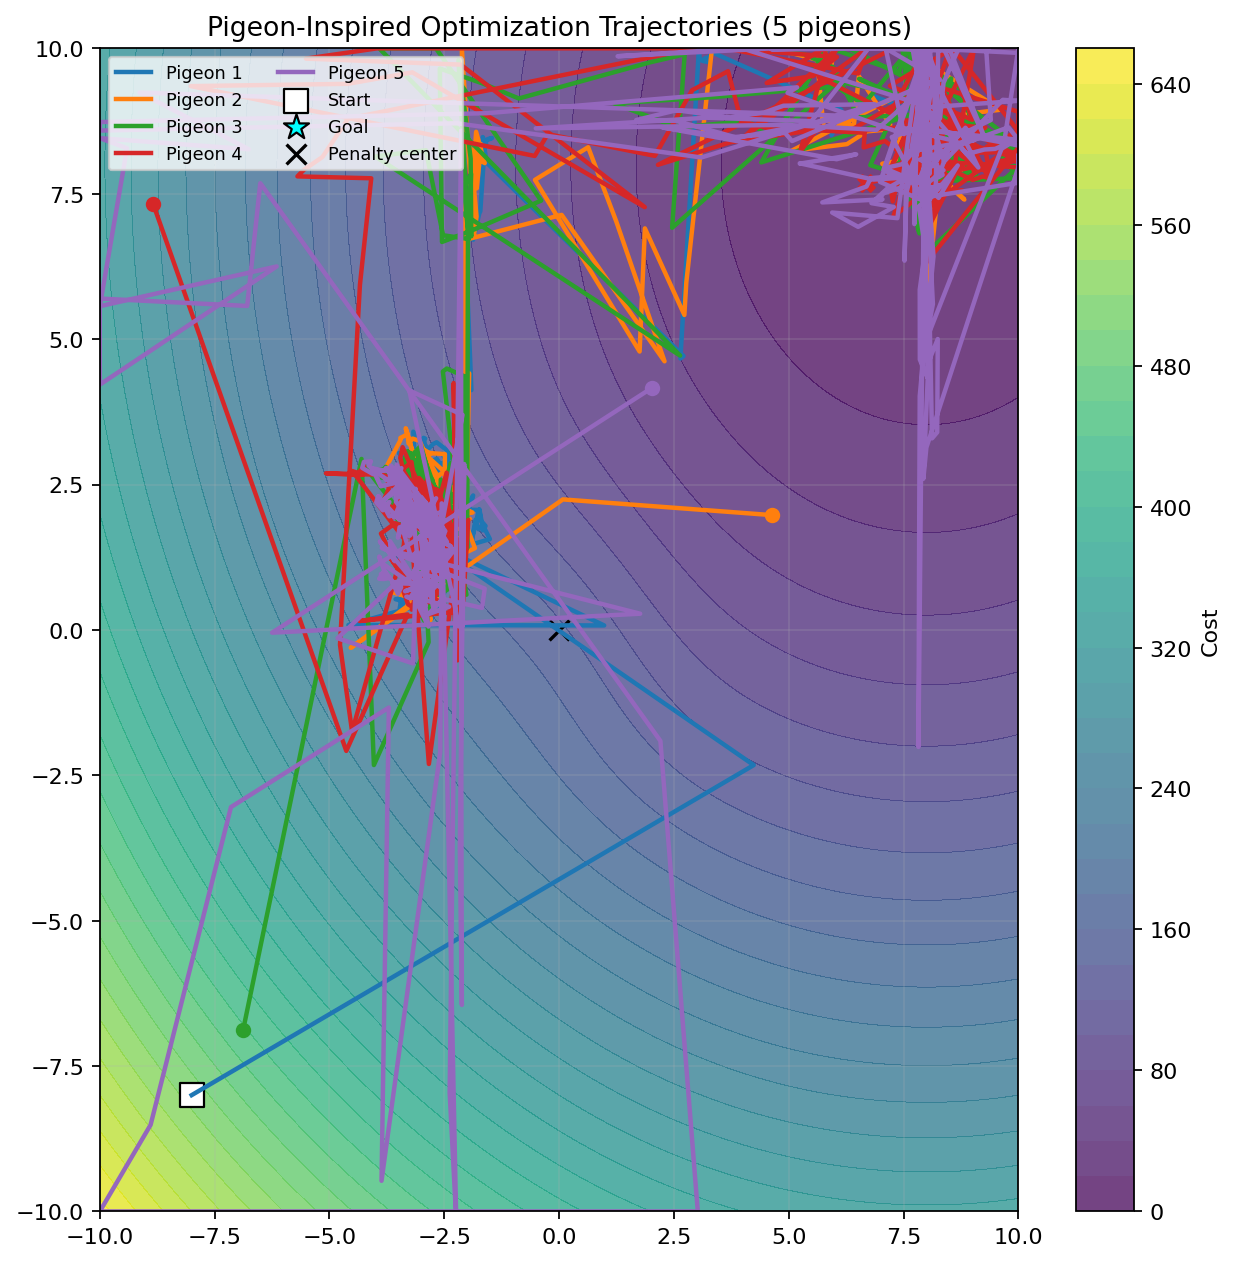

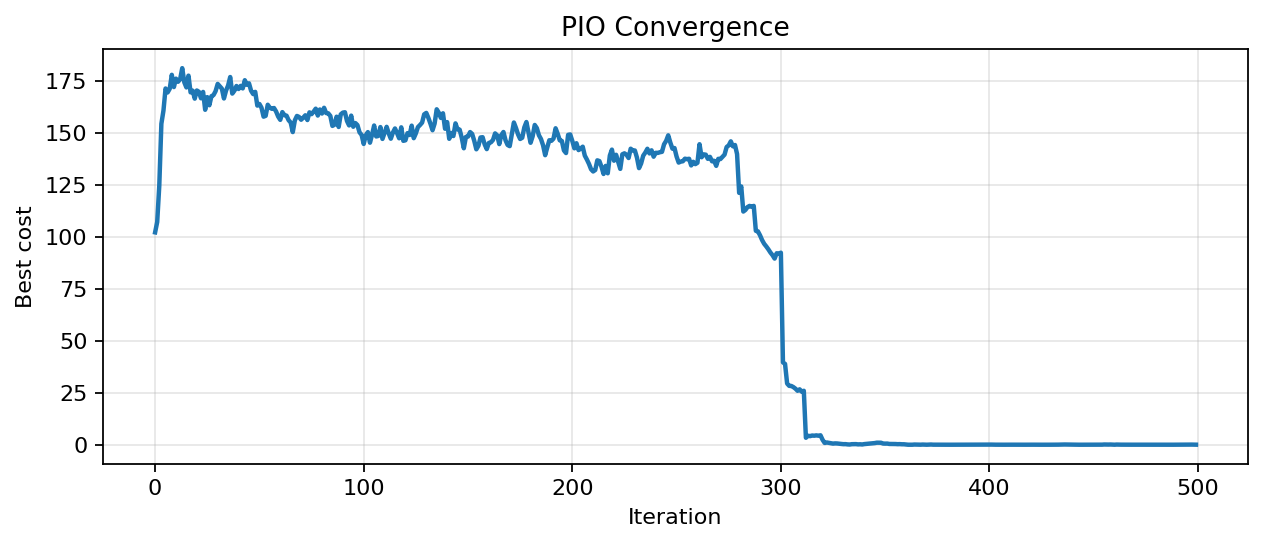

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)

n = 5
iters = 500
bounds = np.array([[-10, 10], [-10, 10]])
start = np.array([-8.0, -8.0])
goal = np.array([8.0, 8.0])

p = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n, 2))
p[0] = start
traj = np.zeros((iters + 1, n, 2))
traj[0] = p
best_hist = []

def cost(x):
    d_goal = np.sum((x - goal) ** 2, axis=-1)
    obstacle = 15.0 * np.exp(-np.sum((x - np.array([0.0, 0.0])) ** 2, axis=-1) / 6.0)
    return d_goal + obstacle

for t in range(iters):
    vals = cost(p)
    idx = np.argsort(vals)
    p = p[idx]

    if t < iters * 0.55:
        center = p.mean(axis=0)
        c1 = 2 * math.exp(-(4 * (t / iters)) ** 2)
        for i in range(n):
            r = np.random.rand(2)
            p[i] = p[i] + c1 * r * (center - p[i]) + 0.15 * np.random.randn(2)
    else:
        best = p[0].copy()
        for i in range(n):
            p[i] = p[i] + 0.6 * np.random.randn(2) * (best - p[i]) + 0.08 * np.random.randn(2)

    p = np.clip(p, bounds[:, 0], bounds[:, 1])
    traj[t + 1] = p
    best_hist.append(cost(p).min())

plt.figure(figsize=(8, 8), dpi=160)
xx = np.linspace(bounds[0, 0], bounds[0, 1], 300)
yy = np.linspace(bounds[1, 0], bounds[1, 1], 300)
X, Y = np.meshgrid(xx, yy)
Z = (X - goal[0])**2 + (Y - goal[1])**2 + 15.0 * np.exp(-((X)**2 + (Y)**2) / 6.0)
plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.75)
plt.colorbar(label="Cost")

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
for i in range(n):
    pts = traj[:, i, :]
    plt.plot(pts[:, 0], pts[:, 1], color=colors[i], linewidth=2, label=f"Pigeon {i+1}")
    plt.scatter(pts[0, 0], pts[0, 1], color=colors[i], s=35, marker="o")
    plt.scatter(pts[-1, 0], pts[-1, 1], color=colors[i], s=55, marker="X")

plt.scatter(start[0], start[1], c="white", edgecolors="black", s=120, marker="s", label="Start")
plt.scatter(goal[0], goal[1], c="cyan", edgecolors="black", s=140, marker="*", label="Goal")
plt.scatter(0, 0, c="black", s=80, marker="x", label="Penalty center")
plt.title("Pigeon-Inspired Optimization Trajectories (5 pigeons)")
plt.xlim(bounds[0])
plt.ylim(bounds[1])
plt.legend(loc="upper left", fontsize=8, ncols=2)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3.5), dpi=160)
plt.plot(best_hist, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title("PIO Convergence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()